In [10]:
import sys
import os
import json
import torch

# Path alignment
sys.path.append(os.path.abspath(os.path.join('..')))
from caption import caption_image_beam_search, visualize_att

# Device and Model setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = '../checkpoints/BEST_checkpoint_coco_5_cap_per_img_5_min_word_freq.pth.tar'
word_map_path = '../dataset/WORDMAP_coco_5_cap_per_img_5_min_word_freq.json'

with open(word_map_path, 'r') as j:
    word_map = json.load(j)
rev_word_map = {v: k for k, v in word_map.items()}

checkpoint = torch.load(model_path, map_location=str(device), weights_only=False)
decoder = checkpoint['decoder'].to(device).eval()
encoder = checkpoint['encoder'].to(device).eval()

Analyzing 9 custom samples...


SOURCE: apple-and-banana-on-a-table.jpg
RESULT: a bunch of ripe bananas sitting on top of a table


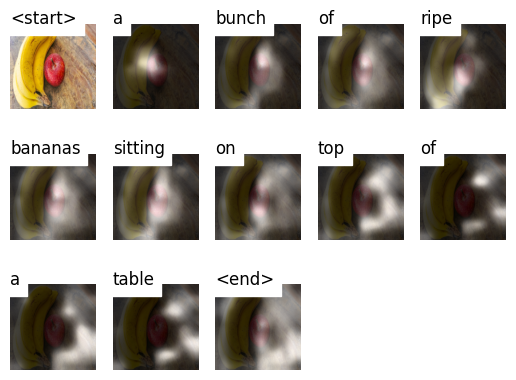


SOURCE: cat-eating-watermelon.jpg
RESULT: a close up of a person holding a toy


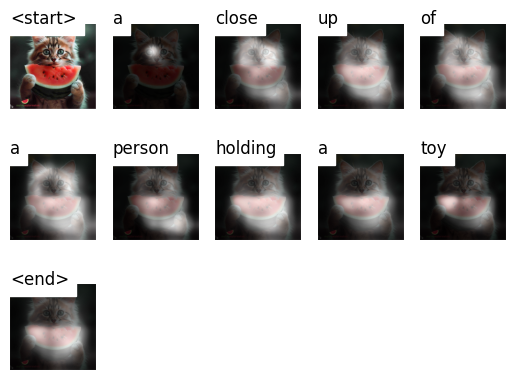


SOURCE: cat-in-paper-tube.jpg
RESULT: a cat that is laying down on a couch


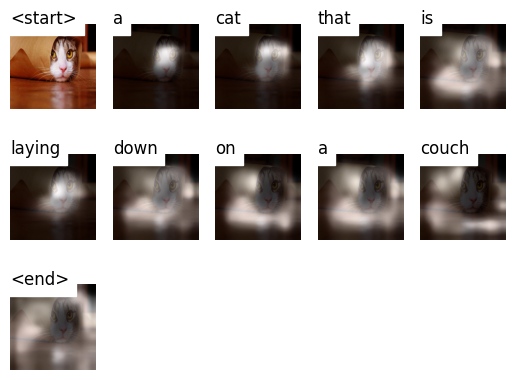


SOURCE: cat-wearing-watermelon-helmet.jpg
RESULT: a small cat is wearing a green hat


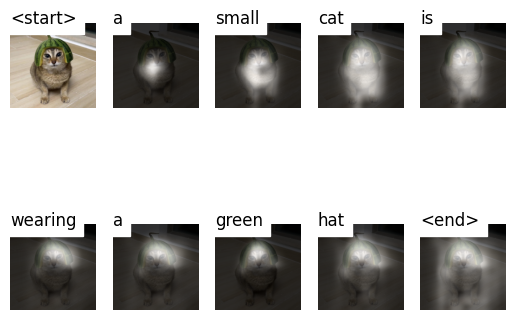


SOURCE: dog-on-a-beach.jpg
RESULT: a white dog standing on top of a sandy beach


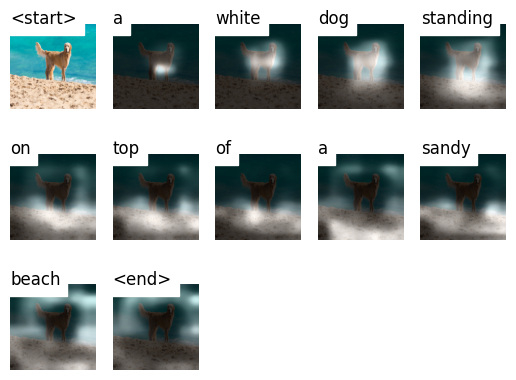


SOURCE: dog-on-a-skateboard.jpg
RESULT: a small dog is riding on a skateboard


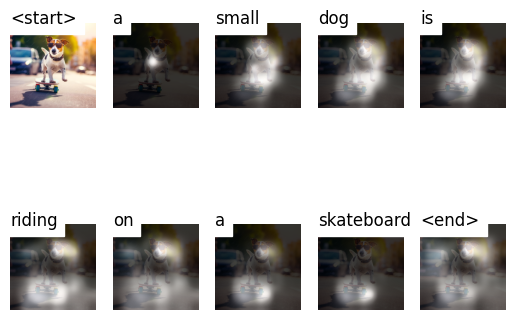


SOURCE: dog-on-grass.jpg
RESULT: a dog sitting in a field of grass


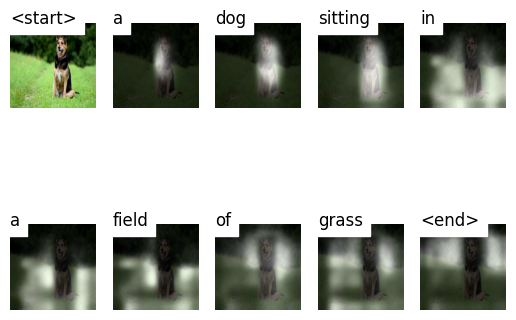


SOURCE: fruits-in-a-basket.jpg
RESULT: a bowl of fruit sitting on a table


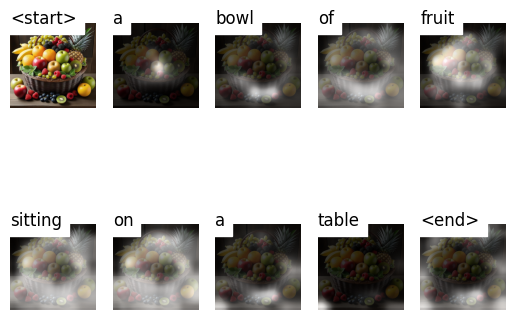


SOURCE: watermelon-cat.jpg
RESULT: a close up of a cake on a plate


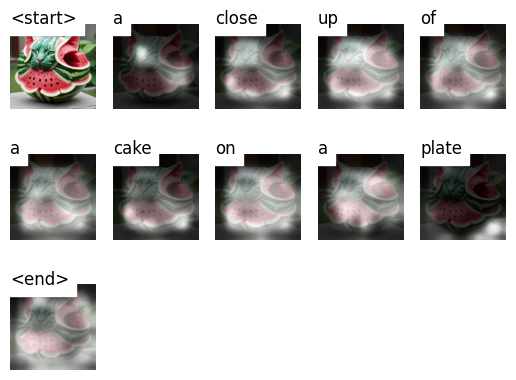

In [13]:
# Updated directory and file list based on your 'ls' output
custom_dir = "../dataset/my_test_images/"  
selected_files = [
    "apple-and-banana-on-a-table.jpg",
    "cat-eating-watermelon.jpg",
    "cat-in-paper-tube.jpg",
    "cat-wearing-watermelon-helmet.jpg",
    "dog-on-a-beach.jpg",
    "dog-on-a-skateboard.jpg",
    "dog-on-grass.jpg",
    "fruits-in-a-basket.jpg",
    "watermelon-cat.jpg",
]

def run_custom_attention_analysis(image_list, k=5):
    """
    Performs qualitative attention analysis on custom images.
    Visualizes how the model grounds linguistic tokens in visual regions.
    """
    print(f"Analyzing {len(image_list)} custom samples...\n")
    
    for filename in image_list:
        fpath = os.path.join(custom_dir, filename)
        
        if not os.path.exists(fpath):
            print(f"Skipping: {filename} (File not found at {fpath})")
            continue
            
        # Inference
        seq, alphas = caption_image_beam_search(encoder, decoder, fpath, word_map, k)
        
        # Sentence reconstruction
        caption = [rev_word_map[i] for i in seq if i not in 
                   {word_map['<start>'], word_map['<end>'], word_map['<pad>']}]
        
        print(f"\n{'='*50}")
        print(f"SOURCE: {filename}")
        print(f"RESULT: {' '.join(caption)}")
        print(f"{'='*50}")
        
        # Attention visualization
        alphas_tensor = torch.FloatTensor(alphas)
        visualize_att(fpath, seq, alphas_tensor, rev_word_map, smooth=True)

# Run visualization
run_custom_attention_analysis(selected_files)